# Análisis Exploratorio de Datos (EDA) - Predicción de Churn
## 1. Introducción y Objetivo del Análisis

Este notebook tiene como objetivo realizar un análisis exhaustivo del conjunto de datos de clientes de Telco para identificar los patrones y factores que impulsan la deserción de clientes (Churn).

**Preguntas Clave:**
- ¿Cuál es el perfil demográfico y de servicios del cliente típico que abandona la empresa?
- ¿Cómo impactan los tipos de contrato y servicios adicionales en la tasa de churn?
- ¿Existe una relación entre la antigüedad, los cargos mensuales y la probabilidad de cancelación?
- ¿Cómo influye la cantidad total de servicios contratados en la lealtad del cliente?

## 2. Perfilado de Datos y Auditoría de Calidad
Carga de datos e inspección inicial de la estructura y tipos de variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pandas.api.types import is_numeric_dtype
from scipy.stats import chi2_contingency
import os

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**Observaciones Iniciales:**
- El dataset consta de 7043 registros y 21 variables.
- La mayoría de las variables son categóricas.
- Se detecta que `TotalCharges` está cargado como texto, requiriendo conversión numérica.

## 3. Diccionario de Datos
Construcción de una tabla resumen detallada para facilitar la comprensión de las variables en la presentación final.

In [3]:
summary_list = []

for col in df.columns:
    if is_numeric_dtype(df[col]):
        min_val = df[col].min()
        max_val = df[col].max()
        summary_list.append({
            'Variable': col,
            'Tipo': 'Numérica',
            'Valores / Rango': f"[{min_val:.2f}, {max_val:.2f}]",
            'Cant. Únicos': 'N/A'
        })
    else:
        uniques = df[col].unique()
        if len(uniques) > 5:
            val_str = ", ".join(map(str, uniques[:5])) + "..."
        else:
            val_str = ", ".join(map(str, uniques))
            
        summary_list.append({
            'Variable': col,
            'Tipo': 'Categórica',
            'Valores / Rango': val_str,
            'Cant. Únicos': len(uniques)
        })

df_summary = pd.DataFrame(summary_list)
display(df_summary)

,Variable,Tipo,Valores / Rango,Cant. Únicos
0,customerID,Categórica,"7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW...",7043
1,gender,Categórica,"Female, Male",2
2,SeniorCitizen,Numérica,"[0.00, 1.00]",N/A
3,Partner,Categórica,"Yes, No",2
4,Dependents,Categórica,"No, Yes",2
5,tenure,Numérica,"[0.00, 72.00]",N/A
6,PhoneService,Categórica,"No, Yes",2
7,MultipleLines,Categórica,"No phone service, No, Yes",3
8,InternetService,Categórica,"DSL, Fiber optic, No",3
9,OnlineSecurity,Categórica,"No, Yes, No internet service",3


## 4. Preprocesamiento y Limpieza de Datos
Tratamiento de tipos de datos y gestión de valores nulos.

In [4]:
# Convertir TotalCharges a numérico y gestionar nulos
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
nulls = df.isnull().sum()
print("Valores nulos por columna:\n", nulls[nulls > 0])

# Eliminación de nulos (cantidad mínima)
df = df.dropna(subset=['TotalCharges'])

print("\nTipos de datos actualizados:\n", df.dtypes)

Valores nulos por columna:
 TotalCharges    11
dtype: int64

Tipos de datos actualizados:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [5]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/df_processed.csv', index=False)

## 5. Análisis del Target: Comportamiento del Churn
Estudio de la distribución de la variable objetivo para detectar desbalances.

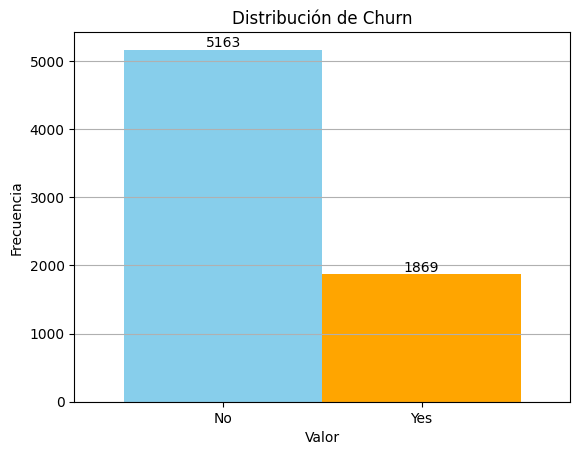

In [6]:
counts = df['Churn'].value_counts()
colores = ['skyblue', 'orange']

ax = counts.plot(kind='bar', width=1.0, color=colores)
plt.title('Distribución de Churn')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.grid(axis='y')
ax.bar_label(ax.containers[0])
plt.show()

**Insight:** Existe un desbalance de clases (más clientes leales que fugados). Se recomienda el uso de métricas como F1-Score o Precision-Recall en el modelado.

## 6. Análisis de Perfil de Cliente (Univariante)
Distribución demográfica y de servicios básicos.

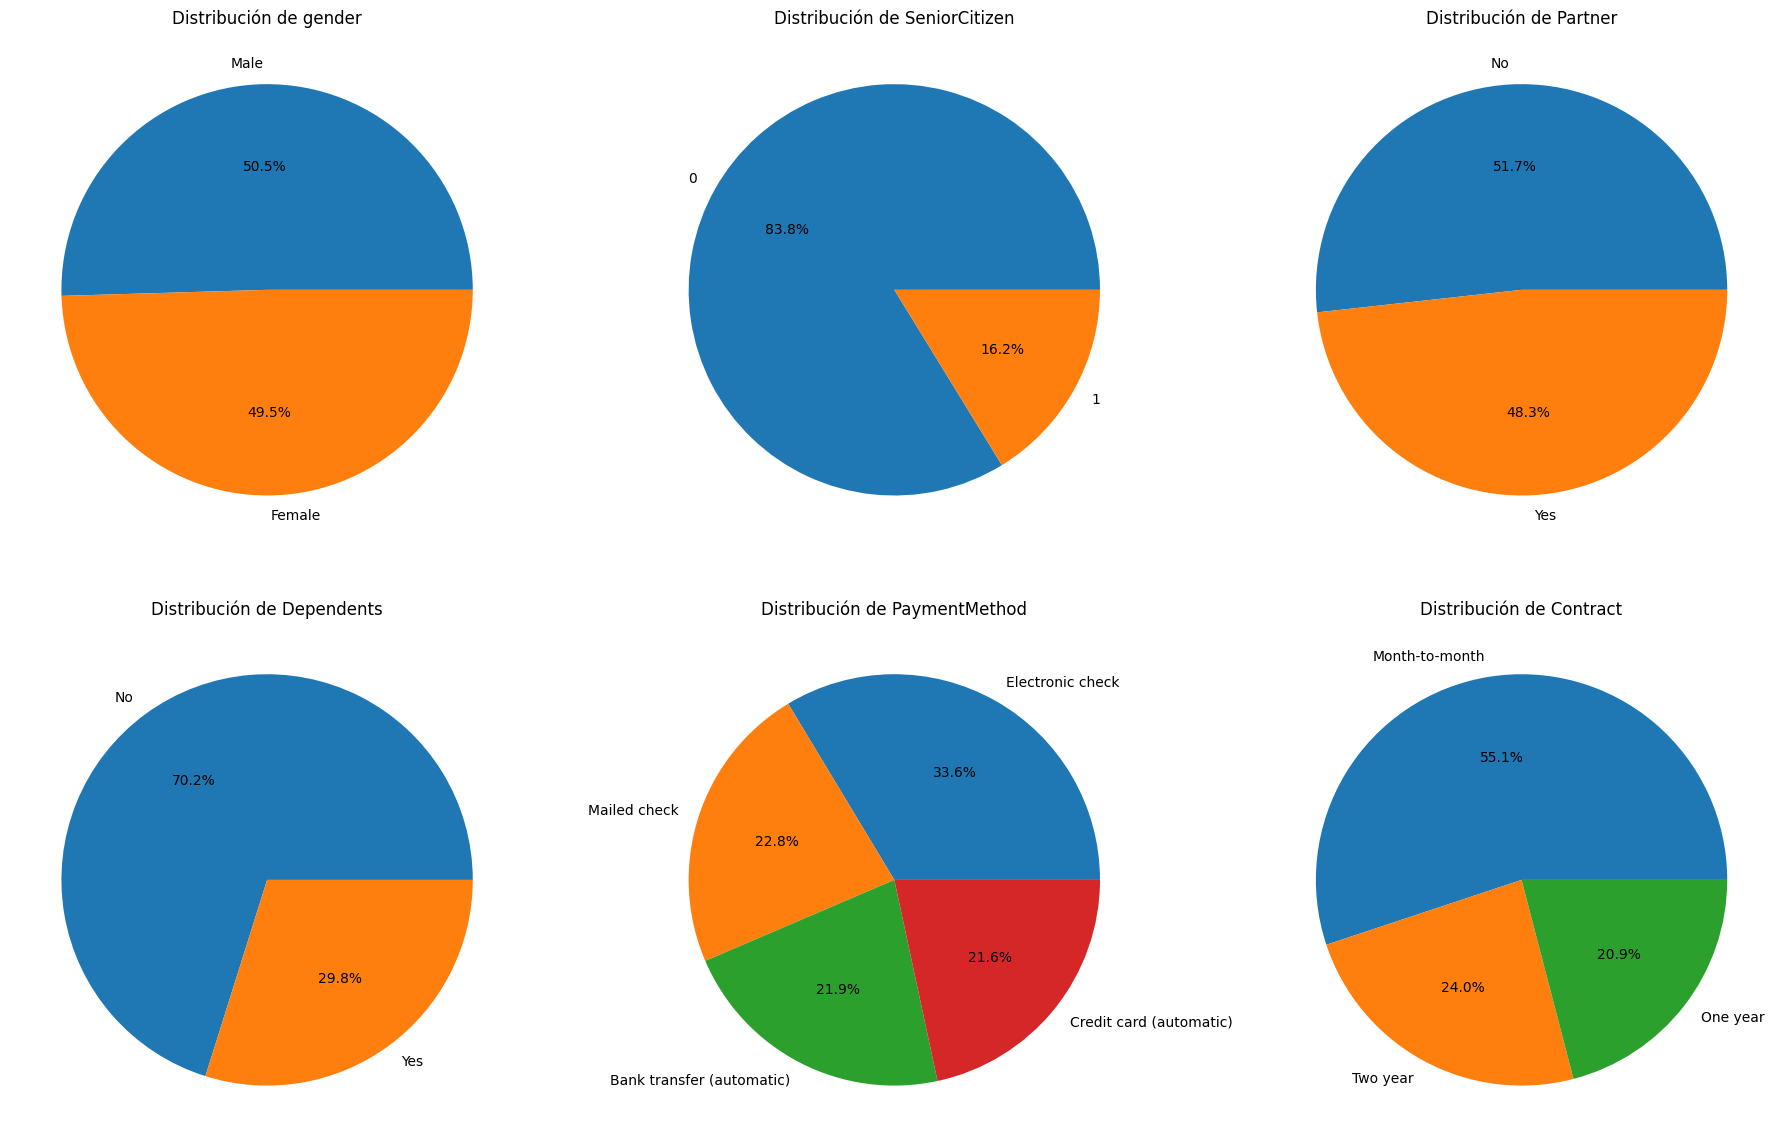

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PaymentMethod', 'Contract']
for i, col in enumerate(cols):
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

**Insight:** Permite identificar la composición de la base de datos y los segmentos predominantes.

## 7. Identificación de Drivers de Churn (Bivariante)
Impacto de variables categóricas sobre la probabilidad de abandono.

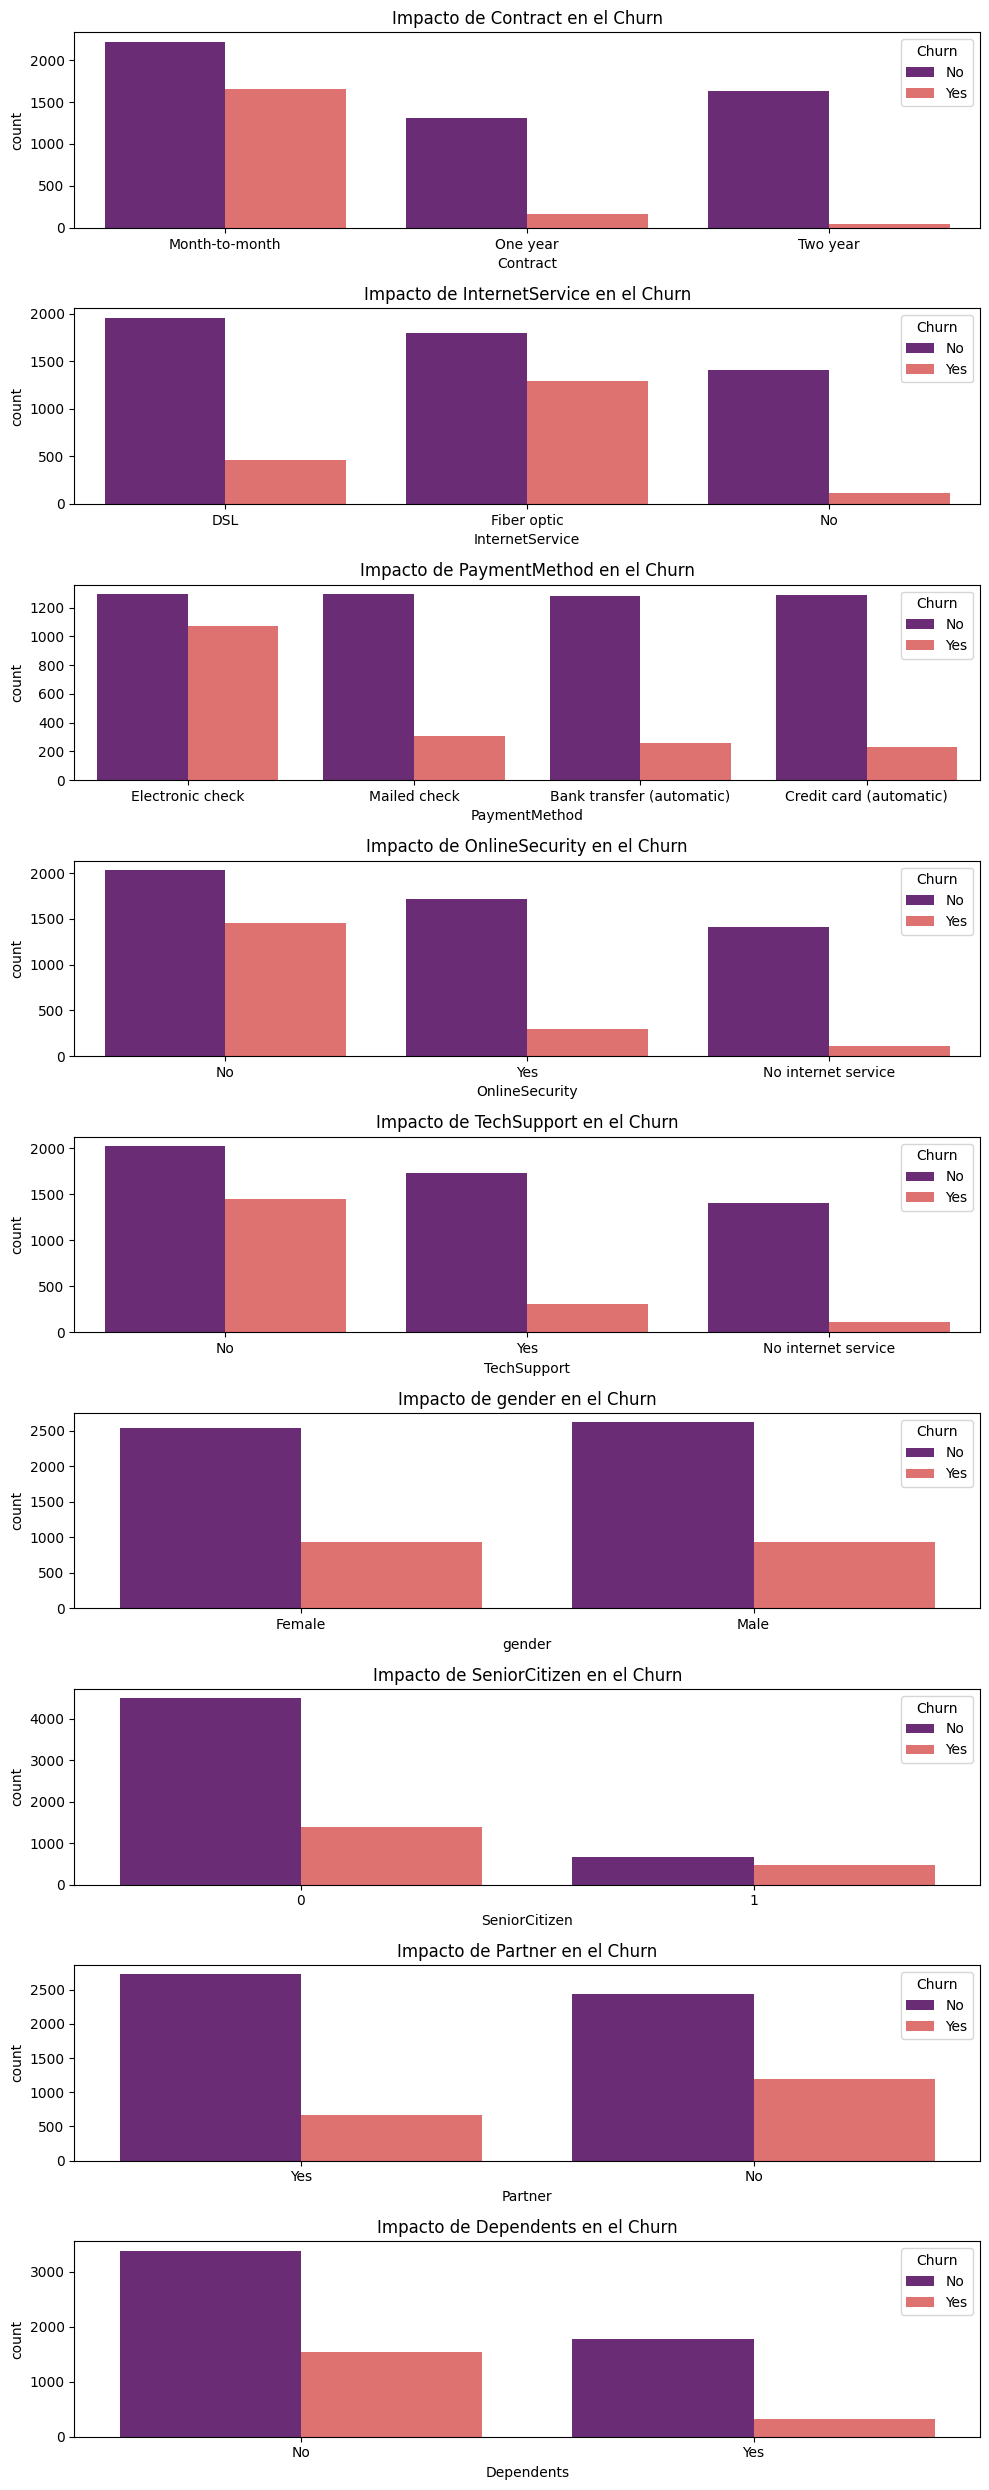

In [8]:
cols_cat = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 
            'gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(len(cols_cat), 1, figsize=(10, 25))

for i, col in enumerate(cols_cat):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'Impacto de {col} en el Churn')
    axes[i].legend(title='Churn', loc='upper right')

plt.tight_layout()
plt.show()

**Insights Clave:**
- **Contratos:** El contrato mes a mes es el mayor predictor de churn.
- **Servicios:** La fibra óptica presenta mayor churn que el DSL.
- **Valor Añadido:** La falta de seguridad en línea y soporte técnico aumenta el riesgo de fuga.

### 7.1. Perfil del Cliente Fugado
Análisis detallado de la distribución de servicios únicamente para los clientes que cancelaron.

/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/3982193885.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_churned, ax=axes[i], palette='Reds_r')
/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/3982193885.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_churned, ax=axes[i], palette='Reds_r')
/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/3982193885.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df_churned, ax=axes[i], palette='Reds

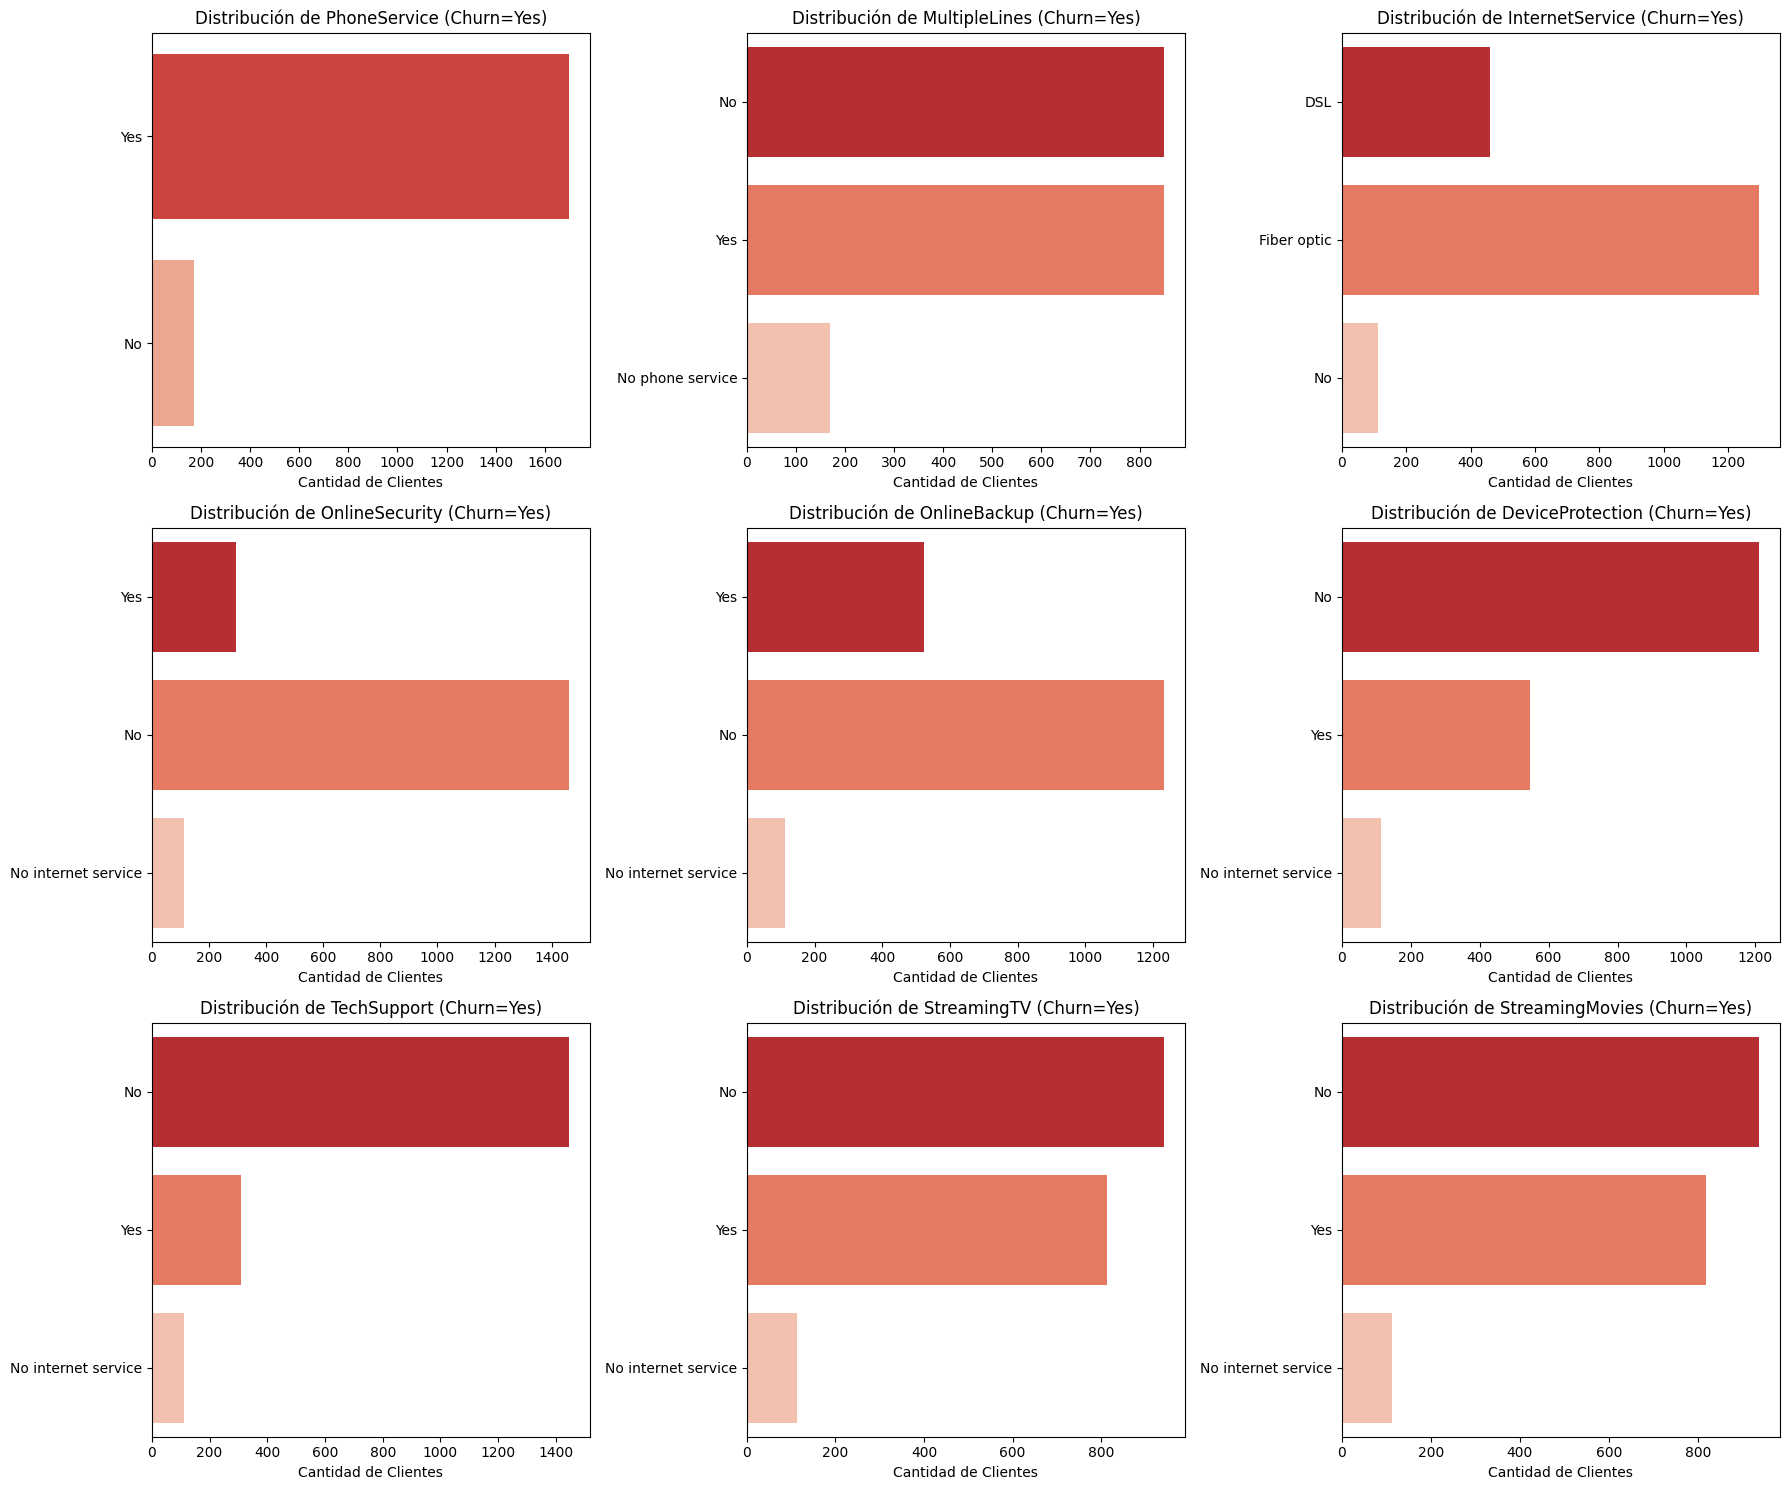

In [9]:
df_churned = df[df['Churn'] == 'Yes']
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    sns.countplot(y=col, data=df_churned, ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Distribución de {col} (Churn=Yes)')
    axes[i].set_xlabel('Cantidad de Clientes')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

**Insight:** Este análisis permite identificar qué servicios son más comunes entre los clientes que abandonan la empresa, ayudando a detectar puntos débiles en la oferta de servicios específicos.

## 8. Análisis de Densidad de Servicios
Estudio de la cantidad de servicios activos y su relación con la lealtad.

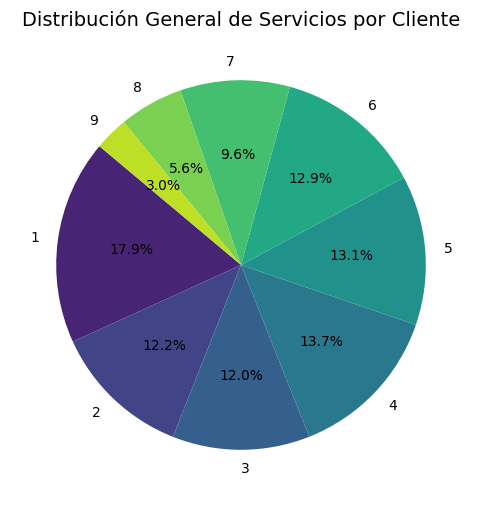

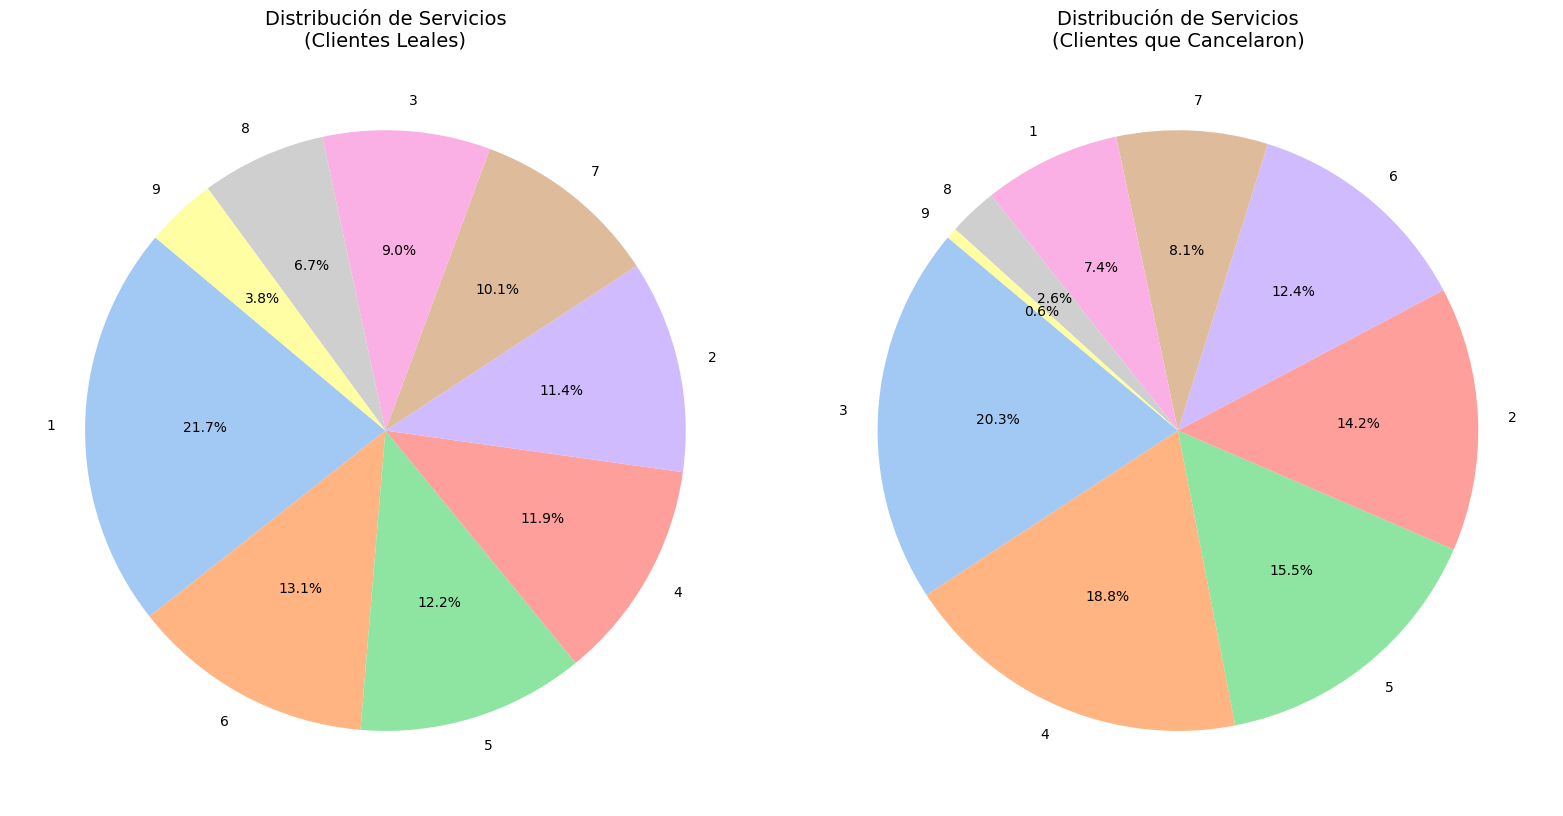

In [10]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_services = df[service_cols].apply(lambda x: x.map(lambda v: 1 if v in ['Yes', 'DSL', 'Fiber optic'] else 0))
df['total_services'] = df_services.sum(axis=1)

# 1. Torta General
plt.figure(figsize=(8, 6))
df['total_services'].value_counts().sort_index().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('viridis', len(df['total_services'].unique())),
    ylabel=''
)
plt.title('Distribución General de Servicios por Cliente', fontsize=14)
plt.show()

# 2. Tortas Comparativas Churn vs No Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

no_churn = df[df['Churn'] == 'No']
no_churn['total_services'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140, 
    ax=axes[0], 
    colors=sns.color_palette('pastel'),
    ylabel=''
)
axes[0].set_title('Distribución de Servicios\n(Clientes Leales)', fontsize=14)

churn_yes = df[df['Churn'] == 'Yes']
churn_yes['total_services'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140, 
    ax=axes[1], 
    colors=sns.color_palette('pastel'),
    ylabel=''
)
axes[1].set_title('Distribución de Servicios\n(Clientes que Cancelaron)', fontsize=14)

plt.tight_layout()
plt.show()

**Insight:** Existe una clara correlación entre la cantidad de servicios y la retención. Los clientes con una cartera de servicios más amplia tienden a ser más leales.

## 9. Análisis de Variables Numéricas y Distribuciones
Análisis de tenure, cargos mensuales y totales segmentados por Churn.

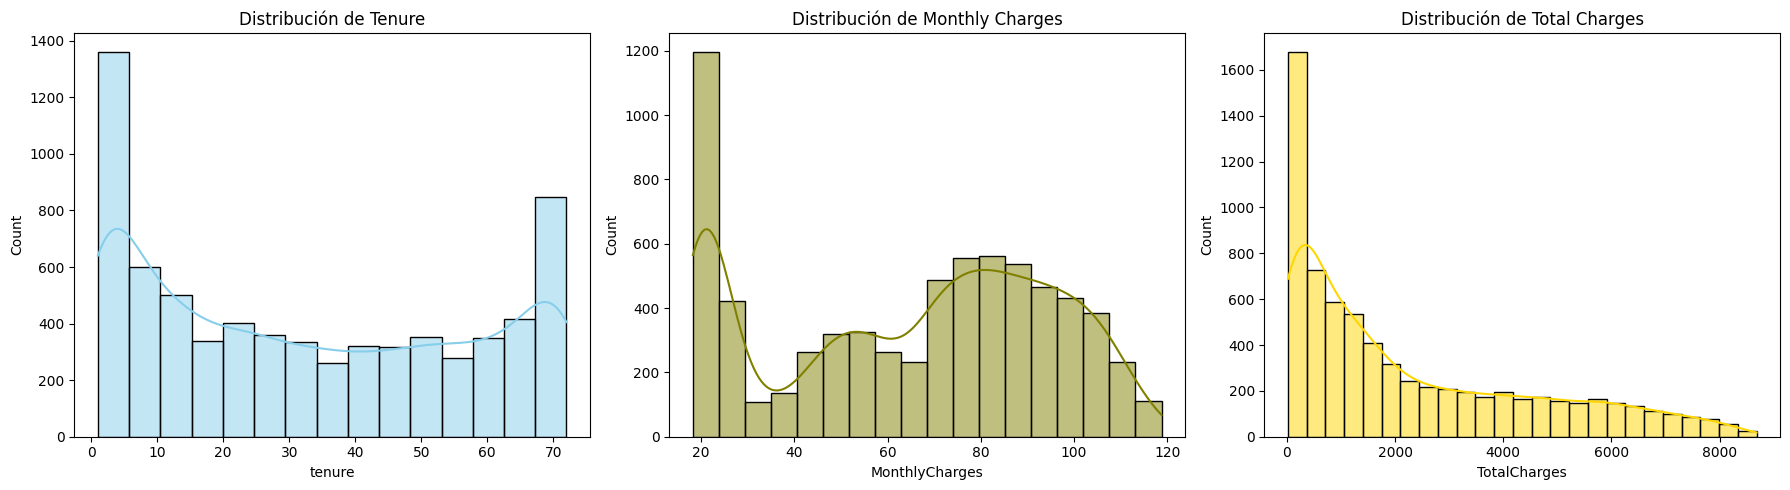

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], kde=True, ax=axes[0], color='skyblue').set_title('Distribución de Tenure')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='olive').set_title('Distribución de Monthly Charges')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2], color='gold').set_title('Distribución de Total Charges')

plt.tight_layout()
plt.show()

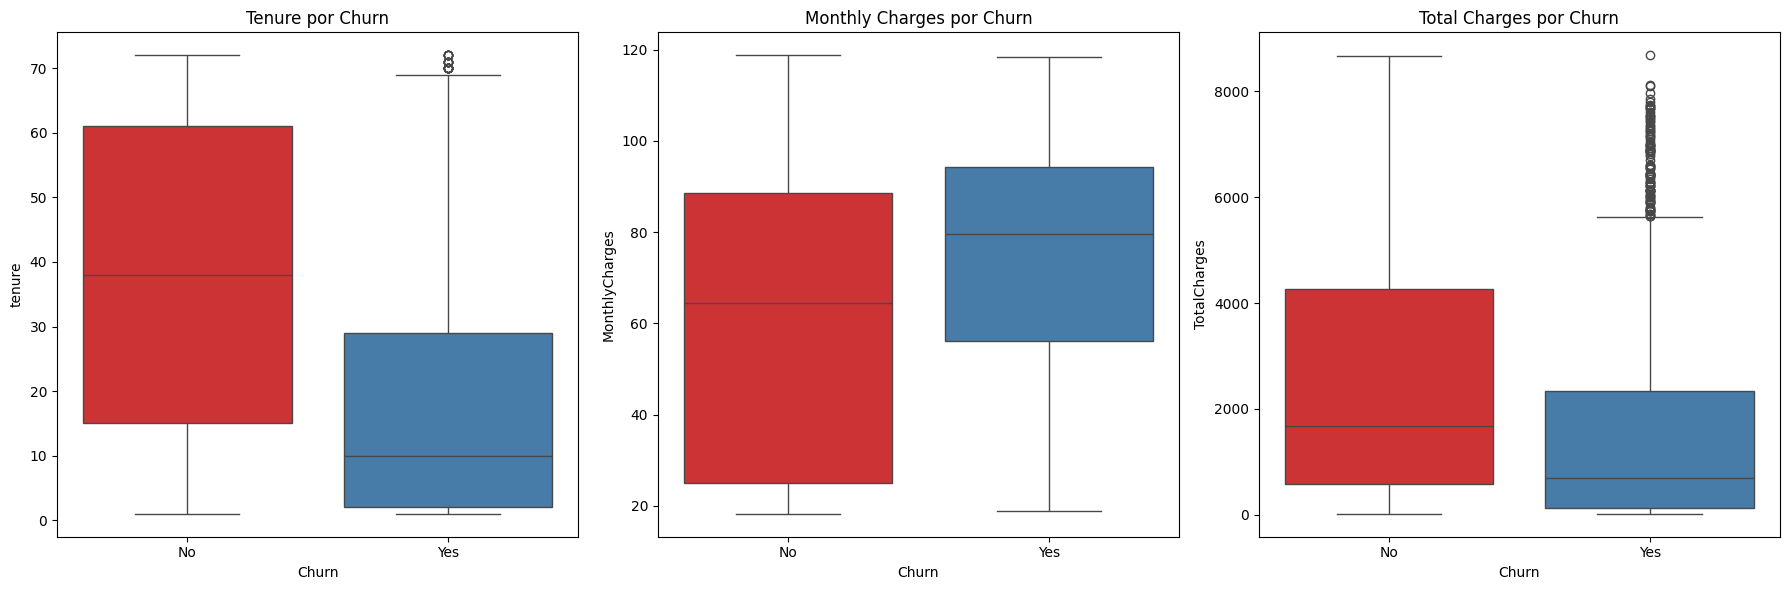

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette='Set1', hue='Churn', legend=False)
axes[0].set_title('Tenure por Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette='Set1', hue='Churn', legend=False)
axes[1].set_title('Monthly Charges por Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[2], palette='Set1', hue='Churn', legend=False)
axes[2].set_title('Total Charges por Churn')

plt.tight_layout()
plt.show()

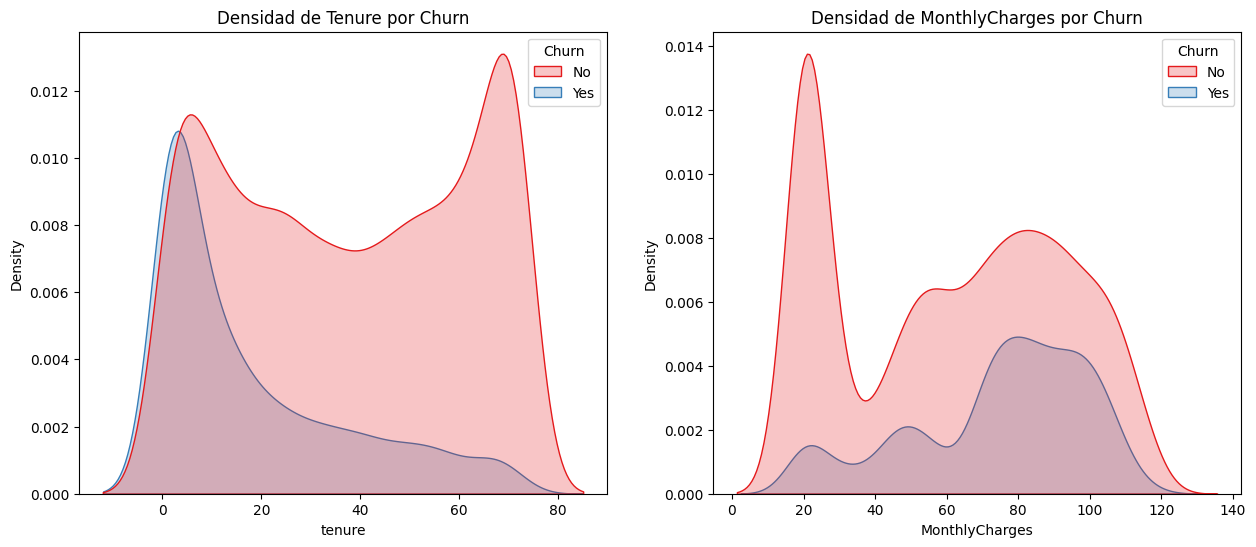

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, ax=axes[0], palette='Set1')
axes[0].set_title('Densidad de Tenure por Churn')

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1], palette='Set1')
axes[1].set_title('Densidad de MonthlyCharges por Churn')

plt.show()

**Insight:** Los clientes con baja antigüedad (`tenure`) y cargos mensuales elevados presentan una probabilidad de churn significativamente mayor.

## 10. Estudio de Correlaciones y Dependencias
Análisis de la relación lineal entre variables numéricas mediante heatmap.

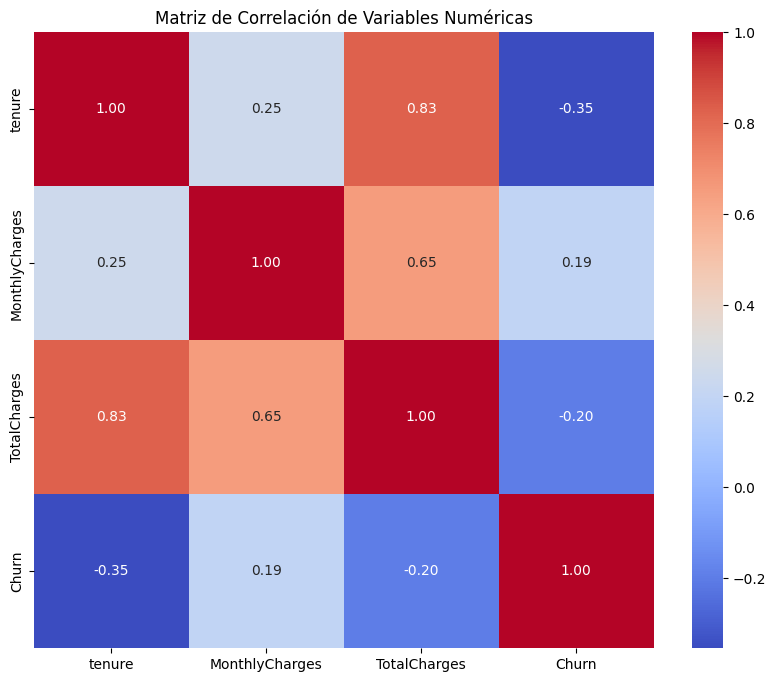

In [14]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
numeric_df = df_corr.select_dtypes(include=[np.number])
numeric_df=numeric_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [15]:
def cramers_v(x, y):
    """ Calcula el V de Cramer con corrección de sesgo. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    
    r, k = confusion_matrix.shape
    
    # Corrección de sesgo (Bias Correction)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/2140270535.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/2140270535.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/2140270535.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/2140270535.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/wx/1ygpz1992l5g023njstmsxxh0000gn/T/ipykernel_22348/2140270535.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
/var/folders/w

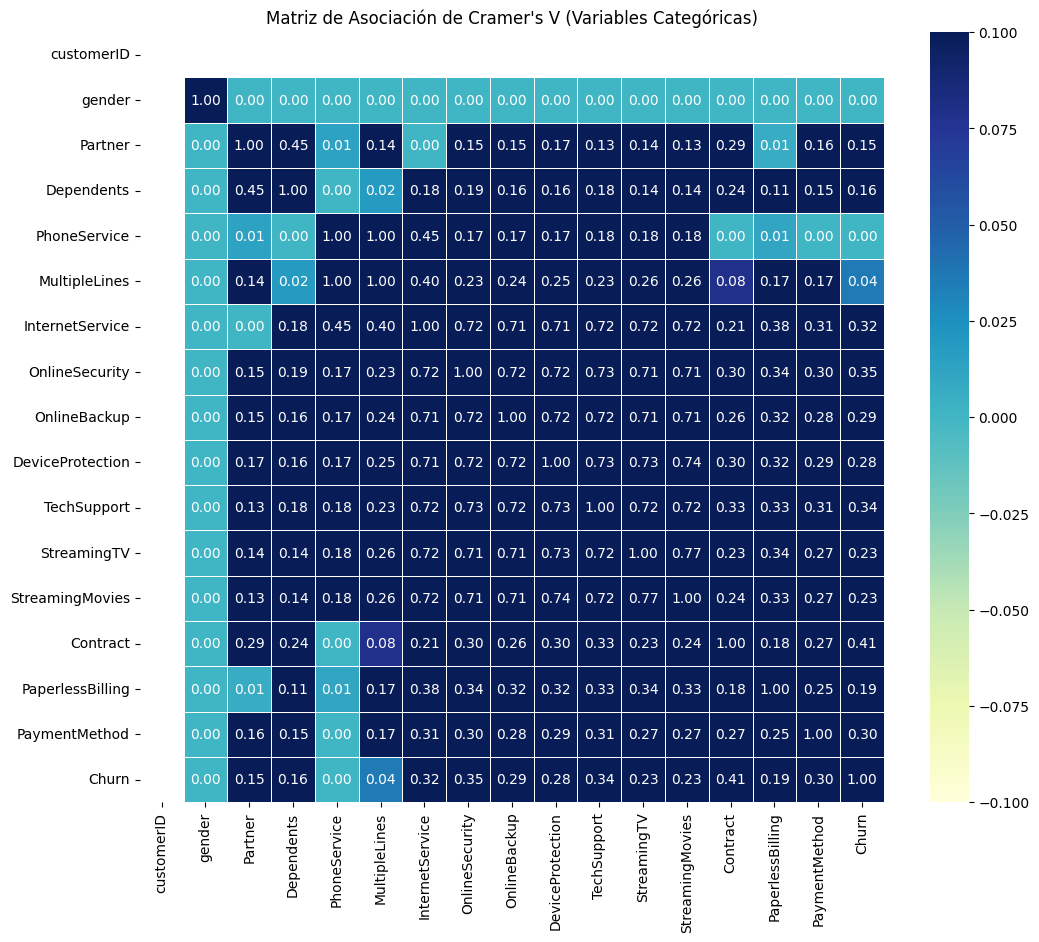

In [16]:
cat_cols = df.select_dtypes(include=['object']).columns

# 2. Crear matriz de asociación
association_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        association_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

association_matrix = association_matrix.astype(float)
#Celda 3: Visualización del Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(association_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title("Matriz de Asociación de Cramer's V (Variables Categóricas)")
plt.show()

**Observaciones:** Alta correlación entre `tenure` y `TotalCharges`. El `MonthlyCharges` tiene una correlación positiva moderada con el Churn.

## 11. Conclusiones Generales y Recomendaciones para el Modelado

**Hallazgos Principales:**
1. **Lealtad:** El tenure es la variable más crítica; los nuevos clientes son el grupo de mayor riesgo.
2. **Contratos:** La migración de contratos mensuales a anuales es la estrategia de retención más viable.
3. **Servicios:** Los clientes con pocos servicios y sin soporte técnico tienden a abandonar más rápido.
4. **Densidad de Servicios:** Los clientes con la cartera de servicios más amplia son significativamente más leales.
5. **Costos:** Existe una correlación entre el precio mensual elevado y la tasa de fuga.

**Siguientes Pasos para el Modelado:**
- Implementar técnicas de balanceo de clases (SMOTE).
- Evaluar el impacto de la multicolinealidad entre tenure y TotalCharges.